# Análise do Campeonato Brasileiro (2003–2024)

Notebook de portfólio: tratamento de dados + análise exploratória (EDA).

**Fonte dos dados:** `brasileirao.csv` (classificação final de cada temporada) e `teams.csv` (dados cadastrais dos clubes).

Estrutura:
1. Setup e carga dos dados
2. Tratamento e limpeza
3. Junção das duas tabelas
4. Colunas derivadas
5. Análise exploratória (EDA)
6. Visualizações


## 1. Setup e carga dos dados



In [1]:
#Importando o Dataset do Brasileirao de 2003 - 2024

import kagglehub

# Download latest version
path = kagglehub.dataset_download("lucasyukioimafuko/brasileirao-serie-a-2006-2022")

print("Path to dataset files:", path)

100%|██████████| 7.54k/7.54k [00:00<00:00, 7.93MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/lucasyukioimafuko/brasileirao-serie-a-2006-2022/versions/19


In [2]:
import pandas as pd
import os

#Listando os arquivos do dataset
arquivos = os.listdir(path)
print('Arquivos encontrados:', arquivos)

Arquivos encontrados: ['teams.csv', 'brasileirao.csv']


In [21]:
#Carregando o csv das tabelas
caminho_arquivo = os.path.join(path, 'brasileirao.csv')
df = pd.read_csv(caminho_arquivo)

In [22]:
display(df.head(24))
print(df.info())

,season,place,team,points,played,won,draw,loss,goals,goals_taken,goals_diff
0,2003,1,Cruzeiro,100,46,31,7,8,102,47,55
1,2003,2,Santos,87,46,25,12,9,93,60,33
2,2003,3,São Paulo,78,46,22,12,12,81,67,14
3,2003,4,São Caetano,74,46,19,14,13,53,37,16
4,2003,5,Coritiba,73,46,21,10,15,67,58,9
5,2003,6,Atlético Mineiro,72,46,19,15,12,76,62,14
6,2003,7,Internacional,72,46,20,10,16,59,57,2
7,2003,8,Flamengo,66,46,18,12,16,66,73,-7
8,2003,9,Goiás,65,46,18,11,17,78,63,15
9,2003,10,Paraná,65,46,18,11,17,85,75,10


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   season       450 non-null    int64 
 1   place        450 non-null    int64 
 2   team         450 non-null    object
 3   points       450 non-null    int64 
 4   played       450 non-null    int64 
 5   won          450 non-null    int64 
 6   draw         450 non-null    int64 
 7   loss         450 non-null    int64 
 8   goals        450 non-null    int64 
 9   goals_taken  450 non-null    int64 
 10  goals_diff   450 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 38.8+ KB
None


In [23]:
#Carregando o csv dos times
caminho_times = os.path.join(path, 'teams.csv')
times = pd.read_csv(caminho_times)

In [24]:
display(times.head())
print(times.info())

,team,acronym,full_name,founded,stadium,city,state,region
0,América Mineiro,AMG,America Futebol Clube,1912,Arena Independencia,Belo Horizonte,Minas Gerais,Southeast
1,América-RN,AFC,America de Natal,1915,Arena America,Natal,Rio Grande do Norte,Northeast
2,Athletico Paranaense,CAP,Club Athletico Paranaense,1924,Arena da Baixada,Curitiba,Parana,South
3,Atlético Goianiense,ACG,Atletico Clube Goianiense,1937,Estadio Antonio Accioly,Goiania,Goias,Central
4,Atlético Mineiro,CAM,Clube Atletico Mineiro,1908,Arena MRV,Belo Horizonte,Minas Gerais,Southeast


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   team       45 non-null     object
 1   acronym    45 non-null     object
 2   full_name  45 non-null     object
 3   founded    45 non-null     int64 
 4   stadium    45 non-null     object
 5   city       45 non-null     object
 6   state      45 non-null     object
 7   region     45 non-null     object
dtypes: int64(1), object(7)
memory usage: 2.9+ KB
None


In [25]:
#Visao sobre os valores nulos
print("Nulos em Df_partidas:\n", df.isnull().sum())
print()
print("Nulos em Df_times:\n", times.isnull().sum())


Nulos em Df_partidas:
 season         0
place          0
team           0
points         0
played         0
won            0
draw           0
loss           0
goals          0
goals_taken    0
goals_diff     0
dtype: int64

Nulos em Df_times:
 team         0
acronym      0
full_name    0
founded      0
stadium      0
city         0
state        0
region       0
dtype: int64


## 2. Tratamento e limpeza

### 2.1 Padronizar nomes de times

Ao comparar as duas tabelas, existe uma inconsistência de nome: o clube aparece como **"Grêmio Barueri"** em `brasileirao.csv`, mas como **"Barueri"** em `teams.csv`. Se isso não for corrigido, o merge entre as tabelas vai gerar uma linha com dados nulos (cidade, estado, estádio) para esse time. Vamos padronizar antes de qualquer coisa.

In [37]:
#Conferindo a diferenca entre os nomes dos times nas duas tabelas
times_df = set(df['team'].unique())
teams_times = set(times['team'].unique())

print('Em df mas nao em times:', times_df - teams_times)
print('Em times mas nao em df:', teams_times - times_df)

Em df mas nao em times: {'Grêmio Barueri'}
Em times mas nao em df: {'Barueri', 'Mirassol'}


In [38]:
#Dicionario de correcao:
correcoes_nome = {
    'Grêmio Barueri': 'Barueri'
}

df['team'] = df['team'].replace(correcoes_nome)

times_df = set(df['team'].unique())
teams_times = set(times['team'].unique())
print('Em df mas nao em times:', times_df - teams_times)
print('Em times mas nao em df:', teams_times - times_df)


Em df mas nao em times: set()
Em times mas nao em df: {'Mirassol'}


### 2.1.2 Nota sobre o Mirassol

Ao comparar as duas tabelas, o Mirassol aparece em `teams.csv` (cadastro de clubes) mas nunca em `brasileirao.csv` (classificações de 2003–2024). Não é um erro: o clube só foi promovido à Série A em 2025, fora do recorte temporal deste projeto. Ele fica de fora dos merges por não ter nenhuma linha de classificação para juntar — não é necessário nenhum tratamento adicional, só o registro de por que ele não aparece nas análises.

### 2.2 Checar duplicatas

Duas checagens: linhas totalmente duplicadas, e duplicidade lógica (mesmo time aparecendo duas vezes na mesma temporada, o que não deveria acontecer).

In [39]:
print('Linhas duplicadas(completas):', df.duplicated().sum())

dup_log = df.duplicated(subset=['season', 'team'])
print('Linhas duplicadas(logicas):', dup_log.sum())

Linhas duplicadas(completas): 0
Linhas duplicadas(logicas): 0


### 2.3 Validar consistência interna

Regras que devem sempre ser verdadeiras nos dados:
- `won + draw + loss == played`
- `points == won*3 + draw*1` (vitória vale 3 pontos, empate 1, desde a adoção do sistema atual)
- `goals_diff == goals - goals_taken`

Se alguma linha quebrar essas regras, é sinal de erro de digitação na fonte original.

In [80]:
inconsistencias = df[
    (df['won'] + df['draw'] + df['loss'] != df['played'])
    | (df['points'] != df['won']*3 + df['draw'] * 1)
    |(df['goals_diff'] != df['goals'] - df['goals_taken'])
].copy()

print(f'Linhas inconsistentes: {len(inconsistencias)}')
inconsistencias

Linhas inconsistentes: 11


,season,place,team,points,played,won,draw,loss,goals,goals_taken,goals_diff
3,2003,4,São Caetano,74,46,19,14,13,53,37,16
6,2003,7,Internacional,72,46,20,10,16,59,57,2
14,2003,15,Corinthians,59,46,15,12,19,61,63,-2
17,2003,18,Juventude,53,46,12,14,20,55,70,-15
18,2003,19,Fluminense,52,46,13,11,22,52,77,-25
19,2003,20,Ponte Preta,50,46,11,18,17,63,73,-10
21,2003,22,Paysandu,49,46,15,12,19,74,77,-3
41,2004,18,São Caetano,53,46,23,8,15,65,49,16
169,2010,20,Barueri,28,38,7,10,21,39,64,-25
225,2013,16,Flamengo,45,38,12,13,13,43,46,-3


Pesquisei sobre essas inconsistencias detalhadamente e obtive uma conclusao, os dados nao estao errados, mas sim incompletos. A ausencia ou bonificacao de pontos reflete a punicao que alguns times sofreram na epoca do campeonato referido e nao foi devidamente especificado.

###Análise das Inconsistências

**Na Tabela:**
*   **`erro_pontos`**: Indica se os pontos no dataset (`points`) divergem do cálculo padrão (Vitórias × 3 + Empates). Se for `True`, houve perda de pontos extra-campo (STJD).
*   **`erro_saldo`**: Indica se o saldo de gols (`goals_diff`) não bate com a conta (Gols Pró - Gols Sofridos).

**No Gráfico:**
*   **Azul (Original/Punição)**: A pontuação oficial registrada, contabilizando punições (ex: Caso Héverton em 2013, Caso Serginho).
*   **Laranja (Teórico)**: O desempenho puramente técnico do time dentro de campo (o que ele conquistou sem as punições).

In [81]:
import pandas as pd

# Recriando as flags de erro nas inconsistências para exibição
inconsistencias['erro_pontos'] = inconsistencias['points'] != (inconsistencias['won'] * 3 + inconsistencias['draw'])
inconsistencias['erro_saldo'] = inconsistencias['goals_diff'] != (inconsistencias['goals'] - inconsistencias['goals_taken'])

# Exibindo a tabela com as colunas relevantes
display(inconsistencias[['season', 'team', 'points', 'won', 'draw', 'goals_diff', 'goals', 'goals_taken', 'erro_pontos', 'erro_saldo']])

,season,team,points,won,draw,goals_diff,goals,goals_taken,erro_pontos,erro_saldo
3,2003,São Caetano,74,19,14,16,53,37,True,False
6,2003,Internacional,72,20,10,2,59,57,True,False
14,2003,Corinthians,59,15,12,-2,61,63,True,False
17,2003,Juventude,53,12,14,-15,55,70,True,False
18,2003,Fluminense,52,13,11,-25,52,77,True,False
19,2003,Ponte Preta,50,11,18,-10,63,73,True,False
21,2003,Paysandu,49,15,12,-3,74,77,True,False
41,2004,São Caetano,53,23,8,16,65,49,True,False
169,2010,Barueri,28,7,10,-25,39,64,True,False
225,2013,Flamengo,45,12,13,-3,43,46,True,False


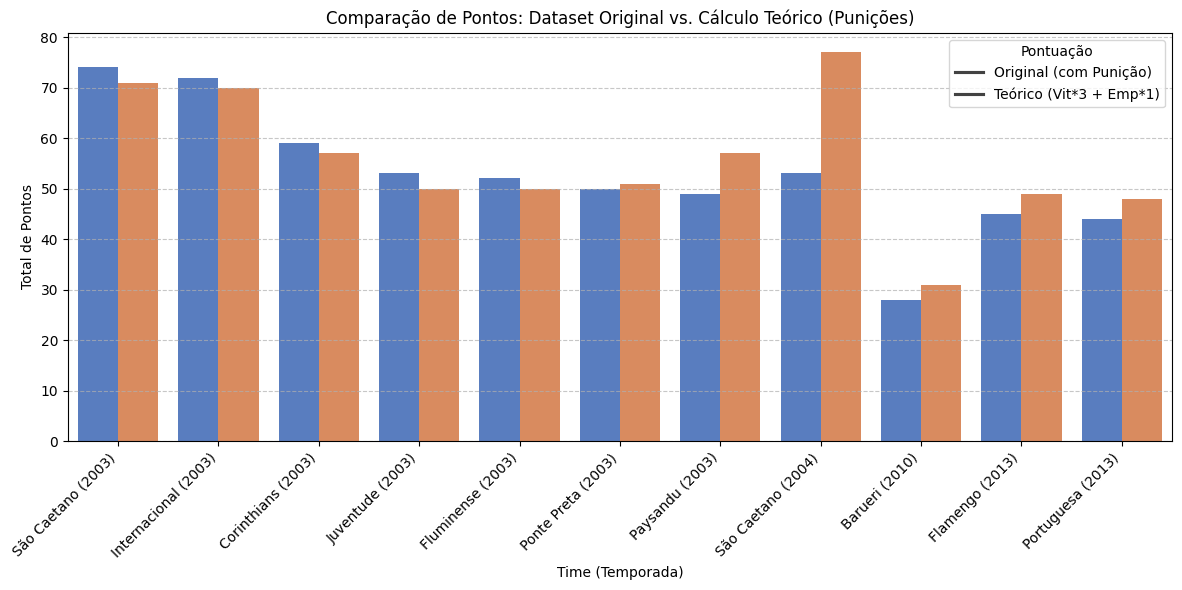

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criando uma cópia das inconsistências para visualização
visualiza_inc = inconsistencias.copy()

# Calculando os pontos teóricos (sem punição: Vitórias * 3 + Empates * 1)
visualiza_inc['pontos_teoricos'] = (visualiza_inc['won'] * 3) + visualiza_inc['draw']
visualiza_inc['label_time'] = visualiza_inc['team'] + " (" + visualiza_inc['season'].astype(str) + ")"

# Preparando os dados para o formato longo (tidy format) exigido pelo seaborn
df_plot = visualiza_inc.melt(id_vars='label_time', value_vars=['points', 'pontos_teoricos'],
                            var_name='Tipo', value_name='Pontos')

# Configurando o estilo e criando o gráfico
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='label_time', y='Pontos', hue='Tipo', palette='muted')

plt.title('Comparação de Pontos: Dataset Original vs. Cálculo Teórico (Punições)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total de Pontos')
plt.xlabel('Time (Temporada)')
plt.legend(title='Pontuação', labels=['Original (com Punição)', 'Teórico (Vit*3 + Emp*1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Junção das duas tabelas (merge)

Agora que os nomes estão padronizados, podemos trazer `state`, `region`, `founded` e `stadium` de `teams.csv` para o dataset principal.

In [53]:
df_full = df.merge(times, on='team', how='left')

#Checagem
print("Linhas sem match no merge:", df_full['region'].isnull().sum())
df_full.head()

Linhas sem match no merge: 0


,season,place,team,points,played,won,draw,loss,goals,goals_taken,goals_diff,acronym,full_name,founded,stadium,city,state,region
0,2003,1,Cruzeiro,100,46,31,7,8,102,47,55,CRU,Cruzeiro Esporte Clube,1942,Mineirao,Belo Horizonte,Minas Gerais,Southeast
1,2003,2,Santos,87,46,25,12,9,93,60,33,SAN,Santos Futebol Clube,1912,Vila Belmiro,Santos,Sao Paulo,Southeast
2,2003,3,São Paulo,78,46,22,12,12,81,67,14,SAO,Sao Paulo Futebol Clube,1930,Estadio do Morumbi,Sao Paulo,Sao Paulo,Southeast
3,2003,4,São Caetano,74,46,19,14,13,53,37,16,SCA,Associacao Desportiva Sao Caetano,1989,Anacleto Campanella,Sao Caetano do Sul,Sao Paulo,Southeast
4,2003,5,Coritiba,73,46,21,10,15,67,58,9,CFC,Coritiba Foot Ball Club,1909,Major Antonio Couto Pereira,Curitiba,Parana,South


## 4. Colunas derivadas

- **Aproveitamento (%)**: `points / (played * 3)`
- **Faixa de classificação**: G4 (Libertadores), meio de tabela, Z4 (rebaixamento)

⚠️ Atenção: o número de rebaixados variou ao longo da história do Brasileirão (de 2 a 4 times, e o número de participantes também mudou — teve temporada com 20, 22 e 24 clubes).

In [63]:
df_full['aproveitamento'] = (df_full['points'] / (df_full['played'] * 3) * 100).round(1)

def faixa_classificacao(row, df_ref):
    total_times = df_ref[df_ref['season'] == row['season']]['team'].nunique()
    if row['place'] <= 4:
        return 'G4 (Libertadores)'
    elif row['place'] > total_times - 4:
        return 'Z4 (Rebaixamento)'
    else:
        return 'Meio de tabela'

df_full['faixa'] = df_full.apply(lambda row: faixa_classificacao(row, df_full), axis=1)

df_full[['season', 'team', 'place', 'points', 'aproveitamento', 'faixa']].head(24)

,season,team,place,points,aproveitamento,faixa
0,2003,Cruzeiro,1,100,72.5,G4 (Libertadores)
1,2003,Santos,2,87,63.0,G4 (Libertadores)
2,2003,São Paulo,3,78,56.5,G4 (Libertadores)
3,2003,São Caetano,4,74,53.6,G4 (Libertadores)
4,2003,Coritiba,5,73,52.9,Meio de tabela
5,2003,Atlético Mineiro,6,72,52.2,Meio de tabela
6,2003,Internacional,7,72,52.2,Meio de tabela
7,2003,Flamengo,8,66,47.8,Meio de tabela
8,2003,Goiás,9,65,47.1,Meio de tabela
9,2003,Paraná,10,65,47.1,Meio de tabela


### 4.1 Filtrando por Ano Específico

Podemos criar uma variável para o ano desejado e filtrar o `df_full` para ver a classificação e o aproveitamento daquela temporada.

In [65]:
# Definindo o ano de interesse
ano_analise = 2024

# Filtrando o DataFrame
df_ano = df_full[df_full['season'] == ano_analise]

# Exibindo os dados ordenados pela posição (place)
display(df_ano[['season', 'team', 'place', 'points', 'aproveitamento', 'faixa']].sort_values('place'))

,season,team,place,points,aproveitamento,faixa
430,2024,Botafogo,1,79,69.3,G4 (Libertadores)
431,2024,Palmeiras,2,73,64.0,G4 (Libertadores)
432,2024,Flamengo,3,70,61.4,G4 (Libertadores)
433,2024,Fortaleza,4,68,59.6,G4 (Libertadores)
434,2024,Internacional,5,65,57.0,Meio de tabela
435,2024,São Paulo,6,59,51.8,Meio de tabela
436,2024,Corinthians,7,56,49.1,Meio de tabela
437,2024,Bahia,8,53,46.5,Meio de tabela
438,2024,Vasco,9,50,43.9,Meio de tabela
439,2024,Cruzeiro,10,49,44.1,Meio de tabela


## 5. Análise exploratória (EDA)

### 5.1 Campeões por temporada e ranking de títulos

In [70]:
campeoes = df_full[df_full['place'] == 1][['season', 'team']].sort_values('season')
print(campeoes.to_string(index=False))

print()

print('Ranking de Titulos de 2003 ate 2024:')
print(campeoes['team'].value_counts())

 season             team
   2003         Cruzeiro
   2004           Santos
   2005      Corinthians
   2006        São Paulo
   2007        São Paulo
   2008        São Paulo
   2009         Flamengo
   2010       Fluminense
   2011      Corinthians
   2012       Fluminense
   2013         Cruzeiro
   2014         Cruzeiro
   2015      Corinthians
   2016        Palmeiras
   2017      Corinthians
   2018        Palmeiras
   2019         Flamengo
   2020         Flamengo
   2021 Atlético Mineiro
   2022        Palmeiras
   2023        Palmeiras
   2024         Botafogo

Ranking de Titulos de 2003 ate 2024:
team
Corinthians         4
Palmeiras           4
Cruzeiro            3
Flamengo            3
São Paulo           3
Fluminense          2
Santos              1
Atlético Mineiro    1
Botafogo            1
Name: count, dtype: int64


### 5.2 Evolução de um time específico ao longo dos anos

Troque `'Flamengo'` pelo time que quiser analisar.

In [74]:
import plotly.express as px
import plotly.graph_objects as go

time_escolhido = 'Flamengo'

hist_time = df_full[df_full['team'] == time_escolhido].sort_values('season')

fig = px.line(
    hist_time, x='season', y ='place', markers = True,
    title = f'Evolucao da posicao final - {time_escolhido}'
)

fig.update_yaxes(autorange = 'reversed', title = 'Posicao final (1º = topo)')
fig.update_xaxes(title = 'Temporada')
fig.show()

### 5.3 Relação entre gols marcados/sofridos e pontos

In [75]:
fig = px.scatter(
    df_full, x='goals', y='points', color='goals_taken',
    hover_name='team', hover_data=['season'],
    title='Gols marcados x Pontos (cor = gols sofridos)',
    labels={'goals': 'Gols marcados', 'points': 'Pontos'}
)
fig.show()

print("Correlação gols marcados x pontos:", df_full['goals'].corr(df_full['points']).round(2))
print("Correlação gols sofridos x pontos:", df_full['goals_taken'].corr(df_full['points']).round(2))


Correlação gols marcados x pontos: 0.75
Correlação gols sofridos x pontos: -0.42


### 5.4 Desempenho por região

In [76]:
por_regiao = df_full.groupby('region')['points'].mean().sort_values(ascending=False).round(1)

fig = px.bar(
    por_regiao, x=por_regiao.index, y=por_regiao.values,
    title='Média de pontos por região',
    labels={'x': 'Região', 'y': 'Média de pontos'}
)
fig.show()


### 5.5 Heatmap de posição final por time x temporada

In [79]:
pivot = df_full.pivot_table(index='team', columns='season', values='place')

fig = px.imshow(
    pivot, color_continuous_scale='RdYlGn_r', aspect='auto',
    title='Posição final por time e temporada (verde = topo, vermelho = rebaixamento)'
)
fig.update_layout(height=900)
fig.show()
